In [1]:
import os
import pandas as pd

DATA_DIR=os.curdir

tables={}

for file in sorted(os.listdir(DATA_DIR)):
    if file.endswith(".csv"):
        file_path=os.path.join(DATA_DIR, file)
        
        try:
            df=pd.read_csv(file_path,low_memory=False)
            tables[file]=df

            print("=" * 70)
            print(f" File Name   : {file}")
            print(f" Shape       : {df.shape[0]} rows × {df.shape[1]} columns")
            print(" Columns     :")

            for col in df.columns:
                print(f"   - {col}")

        except Exception as e:
            print(f" Error loading {file}: {e}")


 File Name   : department_avg_net_stats.csv
 Shape       : 1009788 rows × 5 columns
 Columns     :
   - program_code
   - year
   - lesson_id
   - coefficient_type
   - average_net
 File Name   : department_names.csv
 Shape       : 733 rows × 2 columns
 Columns     :
   - department_name_id
   - department_name
 File Name   : department_placed_pref_uni_type.csv
 Shape       : 513408 rows × 4 columns
 Columns     :
   - program_code
   - year
   - university_type_id
   - placed_pref_count
 File Name   : department_placed_preference_ranks.csv
 Shape       : 3080448 rows × 4 columns
 Columns     :
   - program_code
   - year
   - rank_level
   - count
 File Name   : department_placed_preferences.csv
 Shape       : 128352 rows × 7 columns
 Columns     :
   - program_code
   - year
   - placed_count
   - placed_pref_rank_avg
   - placed_top_1_pref_count
   - placed_top_3_pref_count
   - placed_top_10_pref_count
 File Name   : department_preference_ranks.csv
 Shape       : 1283520 rows × 4 c

In [2]:
metadata=[]

for file, df in tables.items():
    for col in df.columns:
        metadata.append({
            "file_name":file,
            "column_name":col,
            "rows": df.shape[0]
        })

metadata_df=pd.DataFrame(metadata)
metadata_df.to_csv("table_metadata.csv", index=False)


In [3]:
import os
import pandas as pd

DATA_DIR="."

tables={
    f.replace(".csv", ""): pd.read_csv(os.path.join(DATA_DIR, f),low_memory=False)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".csv")
}

In [ ]:
final_df=tables["department_avg_net_stats"]
final_df=final_df.merge(
    tables["lessons"],
    on="lesson_id",
    how="left"
)

final_df=final_df.merge(
    tables["department_placed_preferences"],
    on=["program_code", "year"],
    how="left"
)

final_df=final_df.merge(
    tables["department_placed_preference_ranks"],
    on=["program_code", "year"],
    how="left"
)
final_df=final_df.merge(
    tables["departments_normalized"],
    on="program_code",
    how="left"
)

final_df=final_df.merge(
    tables["department_names"],
    on="department_name_id",
    how="left"
)

final_df=final_df.merge(
    tables["faculty_names"],
    on="faculty_name_id",
    how="left"
)
final_df=final_df.merge(
    tables["universities_normalized"],
    on="university_id",
    how="left"
)

final_df=final_df.merge(
    tables["university_cities"],
    on="university_city_id",
    how="left"
)

final_df=final_df.merge(
    tables["universities_types"],
    on="university_type_id",
    how="left"
)

In [ ]:
final_df=final_df.loc[:, ~final_df.columns.duplicated()]

In [ ]:
final_df.to_csv("final_combined_dataset.csv", index=False)

print("Final shape:", final_df.shape)


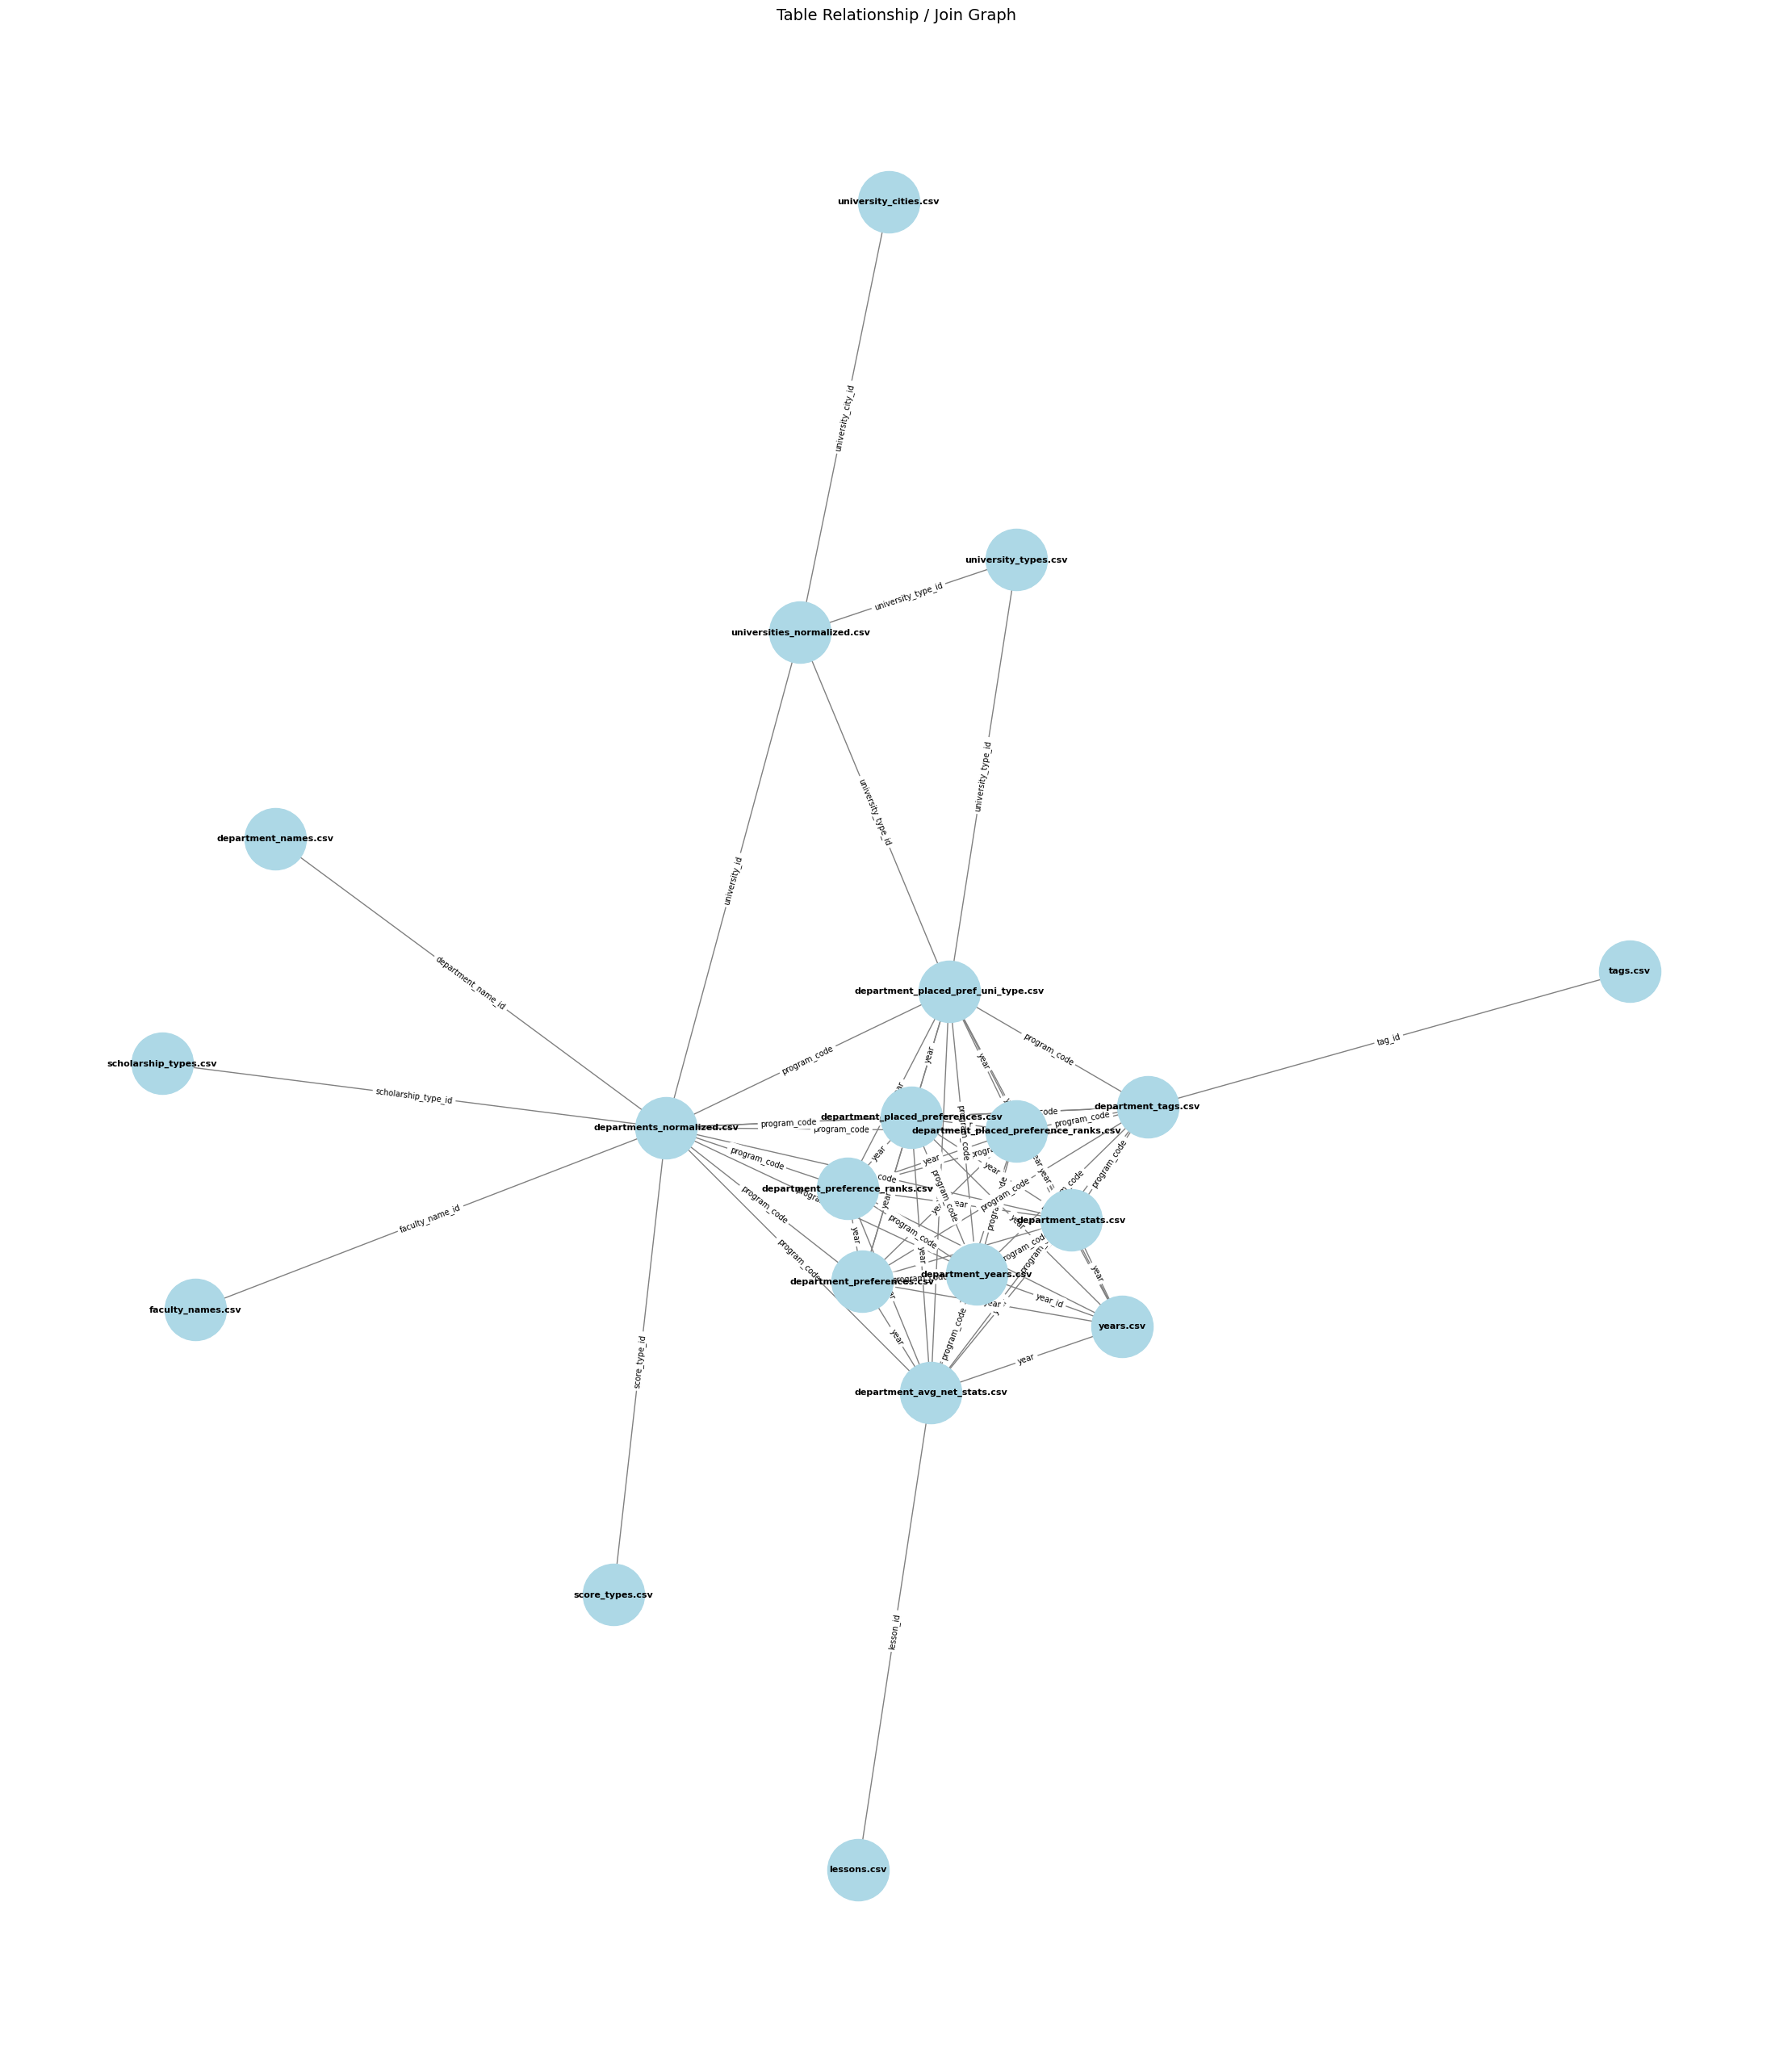

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

meta = pd.read_csv("table_metadata.csv")

joins = (
    meta.groupby("column_name")["file_name"]
    .apply(list)
    .reset_index()
)

joins = joins[joins["file_name"].apply(len) > 1]

G = nx.Graph()

for _, row in joins.iterrows():
    files = row["file_name"]
    col = row["column_name"]

    for i in range(len(files)):
        for j in range(i + 1, len(files)):
            G.add_edge(files[i], files[j], label=col)

plt.figure(figsize=(22, 25))
pos = nx.spring_layout(G, k=0.7)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=8,
    font_weight="bold",
    edge_color="gray"
)

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Table Relationship / Join Graph", fontsize=14)
plt.show()

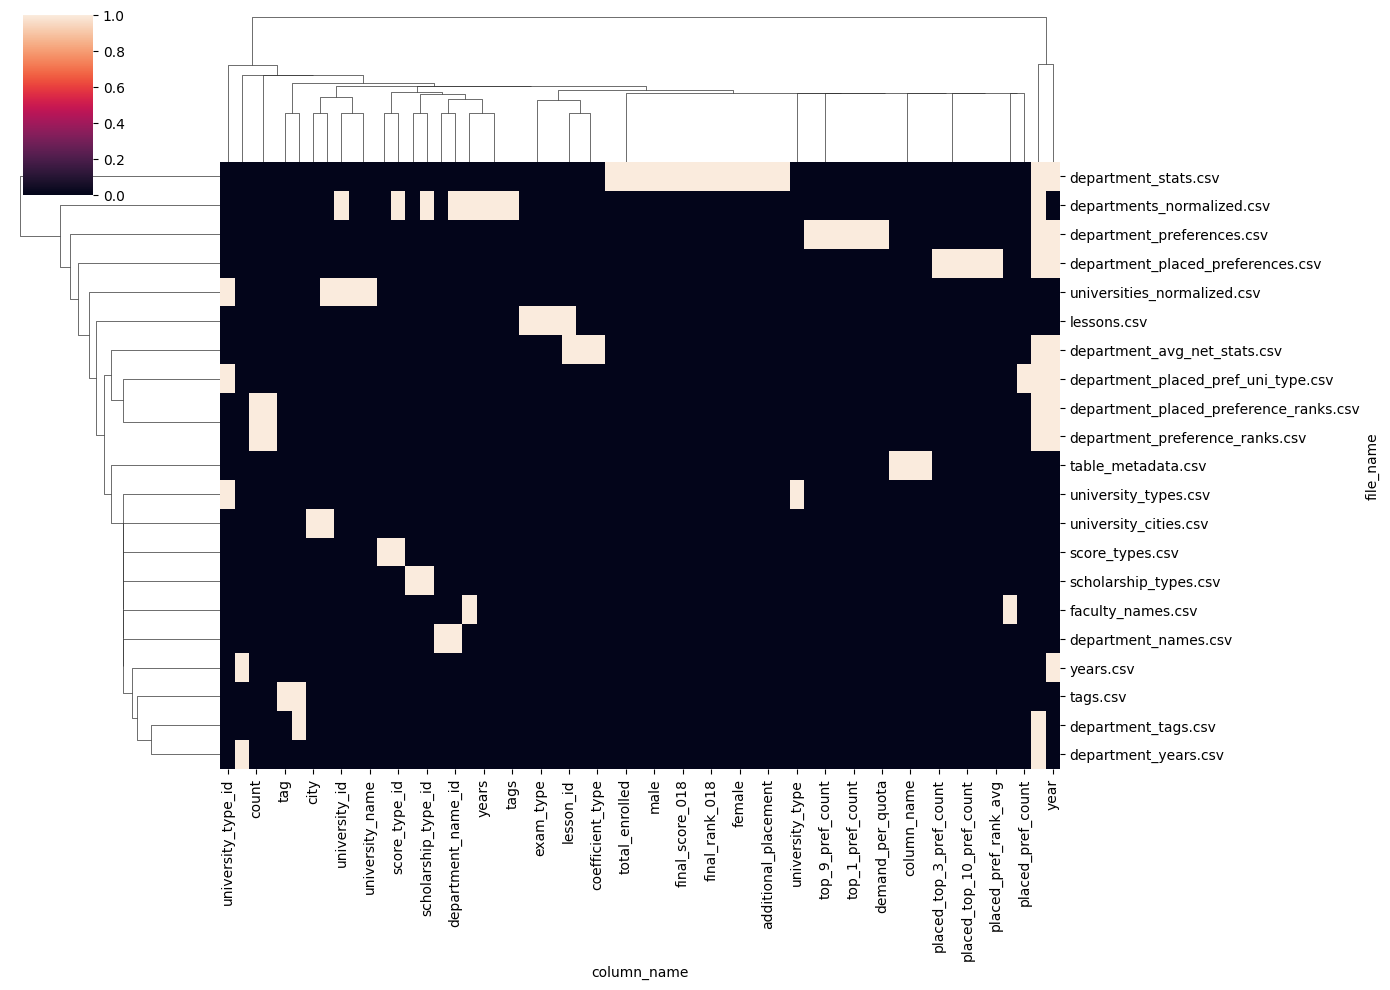

In [8]:
pivot = (
    meta.assign(val=1)
    .pivot_table(index="file_name", columns="column_name", values="val", fill_value=0)
)

import seaborn as sns
sns.clustermap(pivot, figsize=(14, 10))


In [10]:
join_table = (
    joins
    .explode("file_name")
    .sort_values("column_name"))

join_table.to_csv("join_map.csv", index=False)
print(join_table)

            column_name                               file_name
8                 count  department_placed_preference_ranks.csv
8                 count         department_preference_ranks.csv
11   department_name_id                    department_names.csv
11   department_name_id              departments_normalized.csv
14      faculty_name_id              departments_normalized.csv
14      faculty_name_id                       faculty_names.csv
23            lesson_id            department_avg_net_stats.csv
23            lesson_id                             lessons.csv
35         program_code              departments_normalized.csv
35         program_code                    department_years.csv
35         program_code                     department_tags.csv
35         program_code                    department_stats.csv
35         program_code              department_preferences.csv
35         program_code     department_placed_pref_uni_type.csv
35         program_code       department

In [16]:
G_small = G.subgraph([
    "department_avg_net_stats.csv",
    "lessons.csv"])


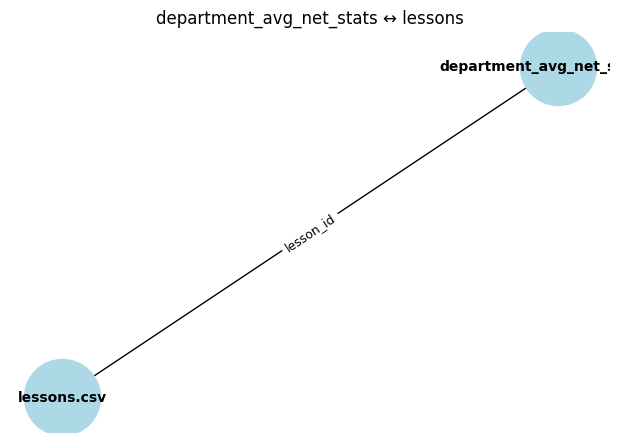

In [17]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(6, 4))

pos = nx.spring_layout(G_small)

nx.draw(
    G_small,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G_small, "label")
nx.draw_networkx_edge_labels(
    G_small,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

plt.title("department_avg_net_stats ↔ lessons")
plt.show()
